# Неделя 3 - EDA, статистический анализ и прогностическое моделирование

**Проект практики:** Анализ данных государственных закупок Республики Казахстан

## Цель Недели 3

На очищенных данных из Недели 2 проводится полный аналитический цикл и строится прогностическая
модель. Это самая насыщенная по технике неделя проекта. Она состоит из четырёх крупных блоков:

1. **Разведочный анализ данных (EDA)** - распределения, корреляции, анализ по категориям и заказчикам.
2. **Статистический анализ** - формальная проверка гипотез (Mann-Whitney, chi-square) с
   интерпретацией p-value.
3. **Инженерия признаков** - построение содержательных предикторов (ранг цены в лоте, уровень
   конкуренции, относительная цена).
4. **Прогностическое моделирование** - сравнение трёх моделей (Logistic Regression, Random Forest,
   Gradient Boosting), подбор гиперпараметров (GridSearch), честная оценка на несбалансированных
   классах (ROC-AUC, precision/recall, матрица ошибок), важность признаков и детектирование аномалий.

**Бизнес-задача:** предсказать, станет ли поданная заявка **победителем** тендера (`Победа`),
и понять, какие факторы определяют победу.

**Основной датасет:** `kraska_clean.csv` (цель `Победа`). Датасет `suppliers_clean.csv` используется
для дополнительного EDA по более широкому набору категорий.


In [ ]:
# Импорты
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PALETTE = ["#1B2A4A", "#E8A838", "#2C7A4B", "#A23B3B", "#3A6EA5"]
print("Среда готова. Все библиотеки импортированы.")

Среда готова. Все библиотеки импортированы.


## 1. Загрузка очищенных данных

Начинаем с чистого слоя данных, подготовленного в Неделе 2. Дополнительно приводим дату публикации к
типу `datetime` для анализа временных трендов.


In [ ]:
kraska = pd.read_csv("kraska_clean.csv")
suppliers = pd.read_csv("suppliers_clean.csv")

kraska["Дата публикации"] = pd.to_datetime(kraska["Дата публикации"], errors="coerce")

print(f"kraska_clean   : {kraska.shape[0]:,} строк x {kraska.shape[1]} столбцов")
print(f"suppliers_clean: {suppliers.shape[0]:,} строк x {suppliers.shape[1]} столбцов")
print()
print("Целевая переменная 'Победа':")
print(kraska["Победа"].value_counts())
print(f"Доля побед: {kraska['Победа'].mean()*100:.1f}%  (классы несбалансированы)")

kraska_clean   : 44,303 строк x 18 столбцов
suppliers_clean: 83,813 строк x 15 столбцов

Целевая переменная 'Победа':
Победа
0    34676
1     9627
Name: count, dtype: int64
Доля побед: 21.7%  (классы несбалансированы)


## 2. Разведочный анализ данных (EDA)

### 2.1 Распределения числовых признаков

Цена и суммы сильно скошены вправо (подтверждено в Неделе 1). Смотрим распределения в логарифмической
шкале, где структура данных видна гораздо лучше.


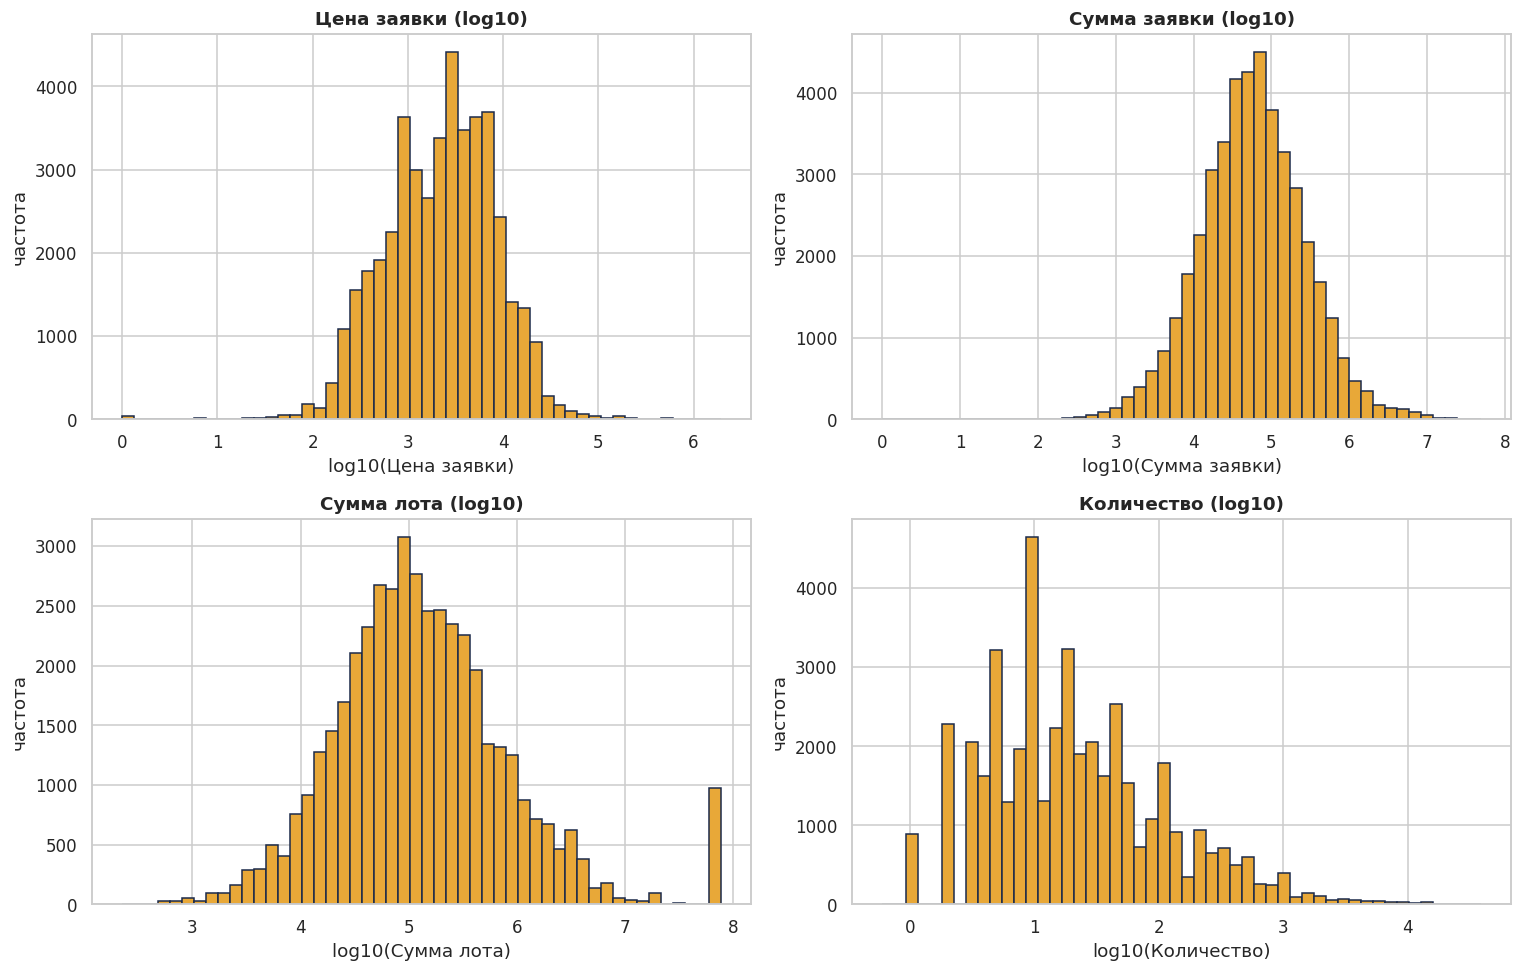

In [ ]:
num_cols = ["Цена заявки", "Сумма заявки", "Сумма лота", "Количество"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), num_cols):
    vals = kraska[col]
    vals = vals[vals > 0]
    ax.hist(np.log10(vals), bins=50, color="#E8A838", edgecolor="#1B2A4A")
    ax.set_title(f"{col} (log10)", fontweight="bold")
    ax.set_xlabel(f"log10({col})")
    ax.set_ylabel("частота")

plt.tight_layout()
plt.savefig("неделя3_распределение.png", dpi=130)
plt.show()

### 2.2 Корреляционная матрица

Изучаем линейные связи между числовыми признаками. Это помогает выявить избыточные (сильно
коррелирующие) признаки до моделирования.


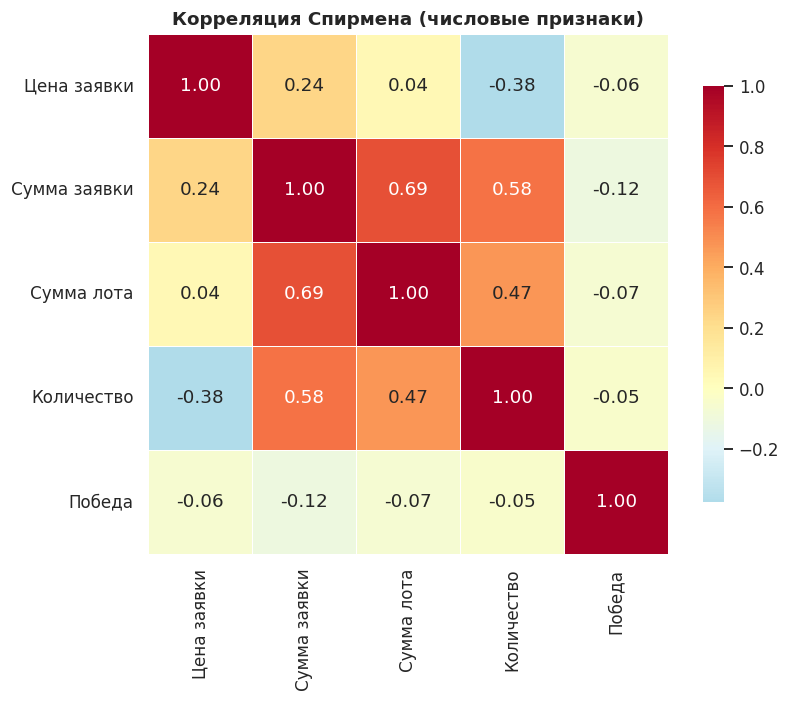

In [ ]:
corr_cols = ["Цена заявки", "Сумма заявки", "Сумма лота", "Количество", "Победа"]
corr = kraska[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Корреляция Спирмена (числовые признаки)", fontweight="bold")
plt.tight_layout()
plt.savefig("неделя3_корреляция.png", dpi=130)
plt.show()

### 2.3 Анализ по заказчикам и категориям

Кто публикует больше всего лотов и где крутятся самые большие суммы. Это даёт бизнес-контекст данным.


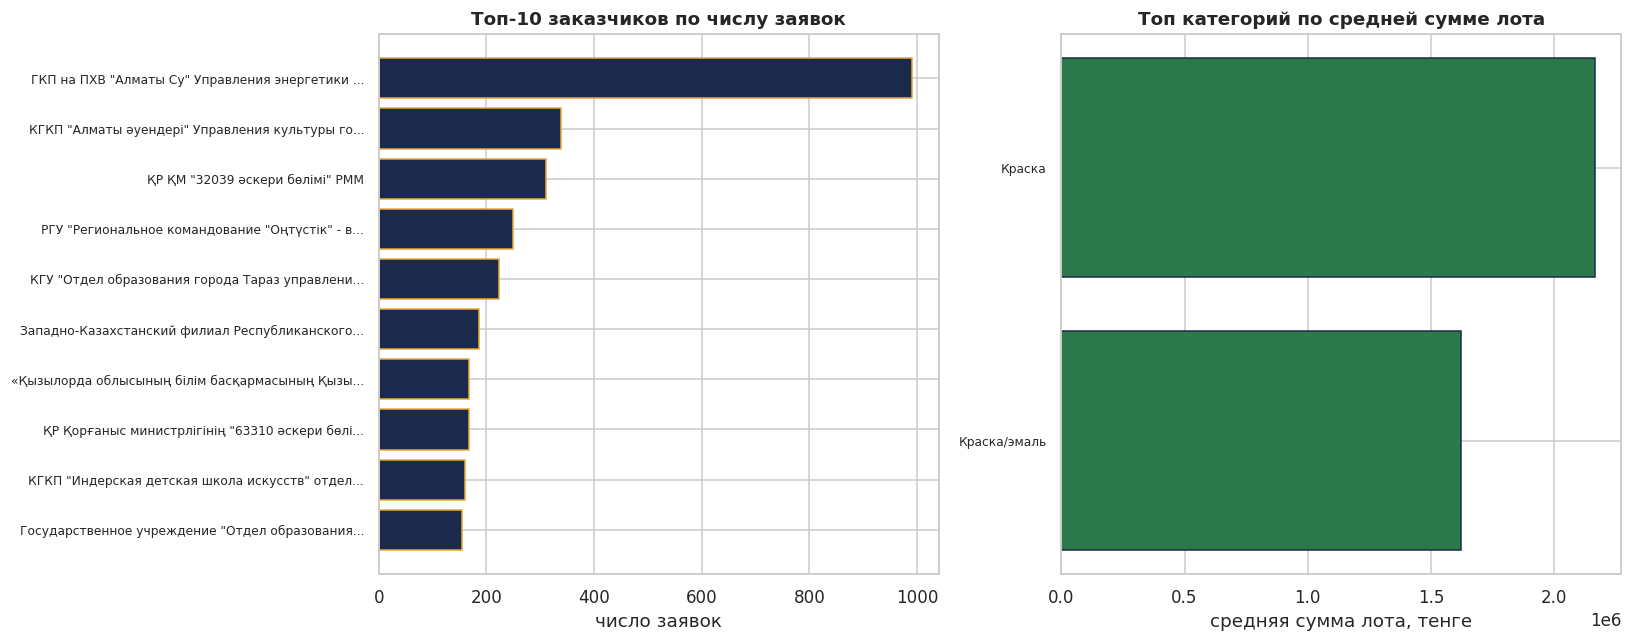

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Топ-10 заказчиков по числу заявок
top_customers = kraska["Наименование заказчика"].value_counts().head(10)
short_names = [n[:45] + "..." if len(n) > 45 else n for n in top_customers.index]
axes[0].barh(range(len(top_customers)), top_customers.values, color="#1B2A4A", edgecolor="#E8A838")
axes[0].set_yticks(range(len(top_customers)))
axes[0].set_yticklabels(short_names, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title("Топ-10 заказчиков по числу заявок", fontweight="bold")
axes[0].set_xlabel("число заявок")

# Средняя сумма лота по топ-категориям КТРУ
top_ktru = kraska.groupby("Наименование КТРУ")["Сумма лота"].agg(["mean", "count"])
top_ktru = top_ktru[top_ktru["count"] >= 30].sort_values("mean", ascending=False).head(10)
axes[1].barh(range(len(top_ktru)), top_ktru["mean"].values, color="#2C7A4B", edgecolor="#1B2A4A")
axes[1].set_yticks(range(len(top_ktru)))
axes[1].set_yticklabels([n[:40] for n in top_ktru.index], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Топ категорий по средней сумме лота", fontweight="bold")
axes[1].set_xlabel("средняя сумма лота, тенге")

plt.tight_layout()
plt.savefig("неделя3_категории_заказчиков.png", dpi=130)
plt.show()

### 2.4 Анализ временных трендов

Как менялись активность закупок и средняя цена заявки по месяцам. Временные тренды - важный
аналитический срез для понимания сезонности и динамики рынка.


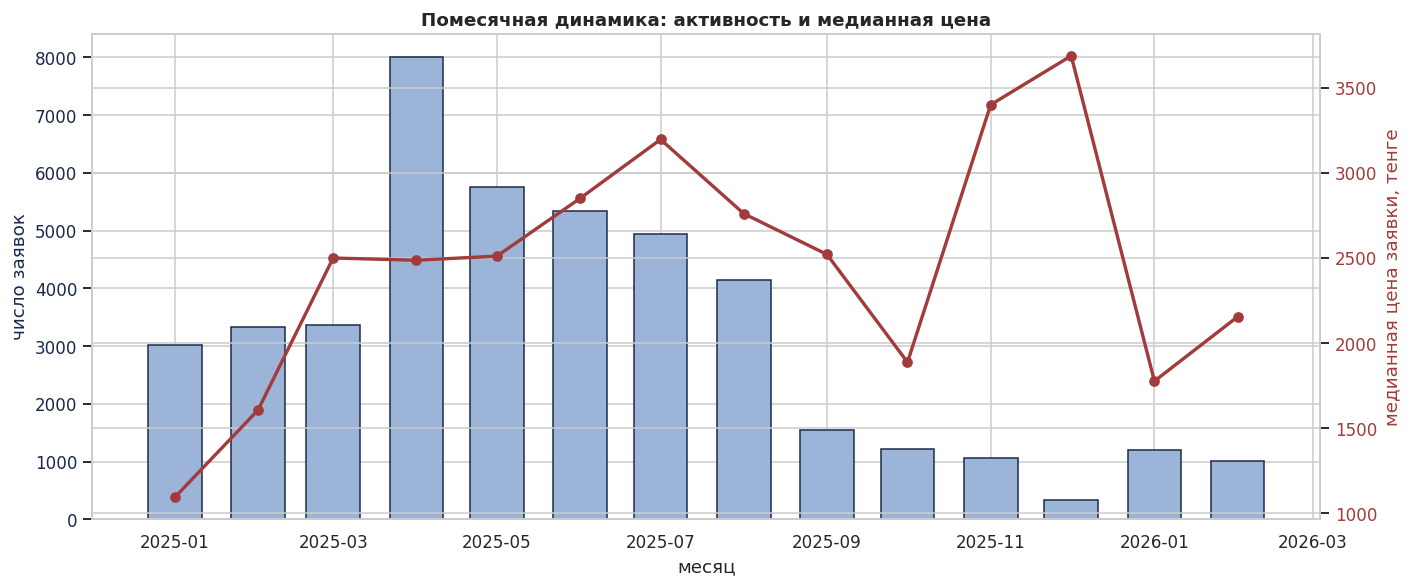

In [ ]:
ts = kraska.dropna(subset=["Дата публикации"]).copy()
ts["Месяц"] = ts["Дата публикации"].dt.to_period("M").dt.to_timestamp()

monthly = ts.groupby("Месяц").agg(
    число_заявок=("Победа", "size"),
    медианная_цена=("Цена заявки", "median"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5.5))

color1 = "#1B2A4A"
ax1.bar(monthly["Месяц"], monthly["число_заявок"], width=20,
        color="#9CB4D8", edgecolor="#1B2A4A", label="число заявок")
ax1.set_ylabel("число заявок", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlabel("месяц")

ax2 = ax1.twinx()
color2 = "#A23B3B"
ax2.plot(monthly["Месяц"], monthly["медианная_цена"], color=color2,
         marker="o", linewidth=2.2, label="медианная цена")
ax2.set_ylabel("медианная цена заявки, тенге", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

ax1.set_title("Помесячная динамика: активность и медианная цена", fontweight="bold")
fig.tight_layout()
plt.savefig("неделя3_временные_тренды.png", dpi=130)
plt.show()

## 3. Статистический анализ - проверка гипотез

Прежде чем строить модель, формально проверим интуитивные предположения статистическими тестами.

### 3.1 Тест 1: отличается ли цена победителей от проигравших?

- **H₀ (нулевая гипотеза):** распределение цены заявки одинаково у победителей и проигравших.
- **H₁ (альтернативная):** распределения различаются.

Цена сильно скошена и не нормальна, поэтому применяем непараметрический критерий **Mann Whitney**
(а не t-тест, который предполагает нормальность).


In [ ]:
winners = kraska[kraska["Победа"] == 1]["Цена заявки"]
losers  = kraska[kraska["Победа"] == 0]["Цена заявки"]

u_stat, p_value = stats.mannwhitneyu(winners, losers, alternative="two-sided")

print("Тест Манна-Уитни: цена победителей vs проигравших")
print(f"  Медиана (победители): {winners.median():,.0f} тг")
print(f"  Медиана (проигравшие): {losers.median():,.0f} тг")
print(f"  U-статистика: {u_stat:,.0f}")
print(f"  p-value: {p_value:.2e}")
print()
alpha = 0.05
if p_value < alpha:
    print(f"  p < {alpha}: отвергаем H0. Различие статистически значимо -")
    print("  цена победителей значимо ниже. Цена - важный фактор победы.")
else:
    print(f"  p >= {alpha}: нет оснований отвергнуть H0.")

Тест Манна-Уитни: цена победителей vs проигравших
  Медиана (победители): 2,246 тг
  Медиана (проигравшие): 2,547 тг
  U-статистика: 153,683,218
  p-value: 9.67e-33

  p < 0.05: отвергаем H0. Различие статистически значимо -
  цена победителей значимо ниже. Цена - важный фактор победы.


### 3.2 Тест 2: связана ли победа с уровнем конкуренции?

Делим лоты на «низкая конкуренция» (мало заявок) и «высокая конкуренция» (много заявок) и проверяем,
связан ли исход (`Победа`) с этой категорией.

- **H₀:** победа не зависит от уровня конкуренции.
- **H₁:** победа зависит от уровня конкуренции.

Для двух категориальных переменных применяем критерий **Chi-Square**.


In [ ]:
# Уровень конкуренции = число заявок на лот
kraska["Конкурентов_в_лоте"] = kraska.groupby("Номер лота")["Номер лота"].transform("count")
median_comp = kraska["Конкурентов_в_лоте"].median()
kraska["Высокая_конкуренция"] = (kraska["Конкурентов_в_лоте"] > median_comp).astype(int)

contingency = pd.crosstab(kraska["Высокая_конкуренция"], kraska["Победа"])
print("Таблица сопряжённости (строки: высокая конкуренция, столбцы: победа):")
print(contingency)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"Критерий хи-квадрат: chi2 = {chi2:,.1f}, dof = {dof}, p-value = {p_value:.2e}")
if p_value < 0.05:
    print("p < 0.05: отвергаем H0. Победа значимо связана с уровнем конкуренции.")
else:
    print("p >= 0.05: связь не подтверждена.")

Таблица сопряжённости (строки: высокая конкуренция, столбцы: победа):
Победа                   0     1
Высокая_конкуренция             
0                    18385  6624
1                    16291  3003

Критерий хи-квадрат: chi2 = 763.3, dof = 1, p-value = 5.24e-168
p < 0.05: отвергаем H0. Победа значимо связана с уровнем конкуренции.


## 4. Инженерия признаков

Создаём содержательные предикторы, которые отражают логику тендера. Самый сильный из них - **ранг
цены внутри лота**: побеждает, как правило, наиболее дешёвая заявка.


In [ ]:
df = kraska.copy()

# Ранг цены внутри лота (1 = самая низкая цена)
df["Ранг_цены"] = df.groupby("Номер лота")["Цена заявки"].rank(method="min")

# Является ли заявка самой дешёвой в лоте
df["min_цена_в_лоте"] = df.groupby("Номер лота")["Цена заявки"].transform("min")
df["Самая_низкая_цена"] = (df["Цена заявки"] == df["min_цена_в_лоте"]).astype(int)

# Относительная цена: насколько заявка отклоняется от средней по лоту
df["mean_цена_в_лоте"] = df.groupby("Номер лота")["Цена заявки"].transform("mean")
df["Относительная_цена"] = df["Цена заявки"] / df["mean_цена_в_лоте"].replace(0, np.nan)

# Доля цены заявки от бюджета лота
df["Цена_к_лоту"] = df["Цена заявки"] / df["Сумма лота"].replace(0, np.nan)

# Лог-преобразования скошенных признаков
df["log_Цена"] = np.log10(df["Цена заявки"].clip(lower=1))
df["log_Количество"] = np.log10(df["Количество"].clip(lower=0.1))
df["log_Сумма_лота"] = np.log10(df["Сумма лота"].clip(lower=1))

# Очистка бесконечностей/NaN в новых признаках
new_feats = ["Относительная_цена", "Цена_к_лоту"]
df[new_feats] = df[new_feats].replace([np.inf, -np.inf], np.nan).fillna(df[new_feats].median())

print("Созданные признаки:")
for f in ["Ранг_цены", "Самая_низкая_цена", "Относительная_цена", "Цена_к_лоту",
          "Конкурентов_в_лоте", "log_Цена", "log_Количество", "log_Сумма_лота"]:
    print(f"  - {f}")

print()
print("Доля побед среди самых дешёвых заявок:",
      f"{df[df['Самая_низкая_цена']==1]['Победа'].mean()*100:.1f}%")
print("Доля побед среди остальных:",
      f"{df[df['Самая_низкая_цена']==0]['Победа'].mean()*100:.1f}%")

Созданные признаки:
  - Ранг_цены
  - Самая_низкая_цена
  - Относительная_цена
  - Цена_к_лоту
  - Конкурентов_в_лоте
  - log_Цена
  - log_Количество
  - log_Сумма_лота

Доля побед среди самых дешёвых заявок: 65.9%
Доля побед среди остальных: 5.5%


## 5. Прогностическое моделирование

### 5.1 Подготовка матрицы признаков

Отбираем признаки, разбиваем на обучающую и тестовую выборки со **стратификацией** (чтобы сохранить
долю классов), и масштабируем числовые признаки для линейной модели.


In [ ]:
features = [
    "Ранг_цены", "Самая_низкая_цена", "Относительная_цена", "Цена_к_лоту",
    "Конкурентов_в_лоте", "log_Цена", "log_Количество", "log_Сумма_лота",
]
target = "Победа"

X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape[0]:,} строк")
print(f"Тестовая выборка : {X_test.shape[0]:,} строк")
print(f"Доля побед (train): {y_train.mean()*100:.1f}% | (test): {y_test.mean()*100:.1f}%")

Обучающая выборка: 33,227 строк
Тестовая выборка : 11,076 строк
Доля побед (train): 21.7% | (test): 21.7%


### 5.2 Сравнение трёх моделей

Обучаем три модели разной природы и сравниваем их по **ROC-AUC** - метрике, устойчивой к дисбалансу
классов (в отличие от accuracy, которая обманчива на несбалансированных данных).

- **Logistic Regression** - линейная базовая модель (используем `class_weight="balanced"`).
- **Random Forest** - ансамбль деревьев, ловит нелинейности.
- **Gradient Boosting** - последовательный бустинг, часто лучшая точность.


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                            random_state=42, n_jobs=1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    # Логистическая регрессия работает на масштабированных данных, деревья - на исходных
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    results[name] = {"model": model, "proba": proba, "auc": auc, "ap": ap}
    print(f"{name:<22}: ROC-AUC = {auc:.4f} | PR-AUC = {ap:.4f}")

best_name = max(results, key=lambda k: results[k]["auc"])
print()
print(f"Лучшая модель по ROC-AUC: {best_name}")

Logistic Regression   : ROC-AUC = 0.9288 | PR-AUC = 0.7346
Random Forest         : ROC-AUC = 0.9750 | PR-AUC = 0.9396
Gradient Boosting     : ROC-AUC = 0.9783 | PR-AUC = 0.9428

Лучшая модель по ROC-AUC: Gradient Boosting


### 5.3 ROC-кривые трёх моделей

Визуальное сравнение качества классификаторов. Чем ближе кривая к левому верхнему углу, тем лучше.


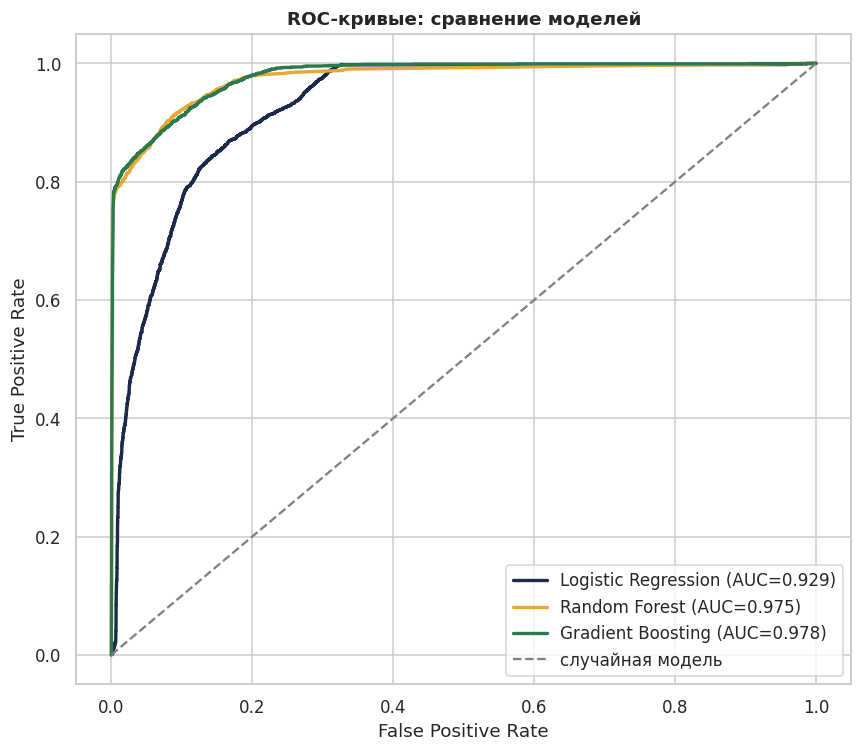

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
for (name, res), color in zip(results.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", linewidth=2.2, color=color)

ax.plot([0, 1], [0, 1], "--", color="gray", label="случайная модель")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-кривые: сравнение моделей", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("неделя3_roc_кривые.png", dpi=130)
plt.show()

### 5.4 Подбор гиперпараметров (GridSearchCV)

Берём лучшую по природе модель (Gradient Boosting) и оптимизируем её гиперпараметры через перебор по
сетке с кросс-валидацией (стратифицированная 4-fold). Оптимизируем по ROC-AUC.


In [ ]:
param_grid = {
    "n_estimators": [250],
    "max_depth": [2, 3],
    "learning_rate": [0.1],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=0,
)
grid.fit(X_train, y_train)

print("Лучшие гиперпараметры:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nЛучший ROC-AUC на кросс-валидации: {grid.best_score_:.4f}")

# Оценка настроенной модели на тесте
best_model = grid.best_estimator_
proba_tuned = best_model.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, proba_tuned)
print(f"ROC-AUC настроенной модели на тесте: {auc_tuned:.4f}")

Лучшие гиперпараметры:
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 250

Лучший ROC-AUC на кросс-валидации: 0.9800
ROC-AUC настроенной модели на тесте: 0.9784


### 5.5 Детальная оценка настроенной модели

ROC-AUC показывает общее качество, но на несбалансированных данных важно смотреть **матрицу ошибок**
и **precision/recall**. Выбираем порог и разбираем, какие ошибки делает модель.


Отчёт классификации (порог = 0.5):
              precision    recall  f1-score   support

   Не победа       0.95      0.99      0.97      8669
      Победа       0.95      0.81      0.87      2407

    accuracy                           0.95     11076
   macro avg       0.95      0.90      0.92     11076
weighted avg       0.95      0.95      0.95     11076



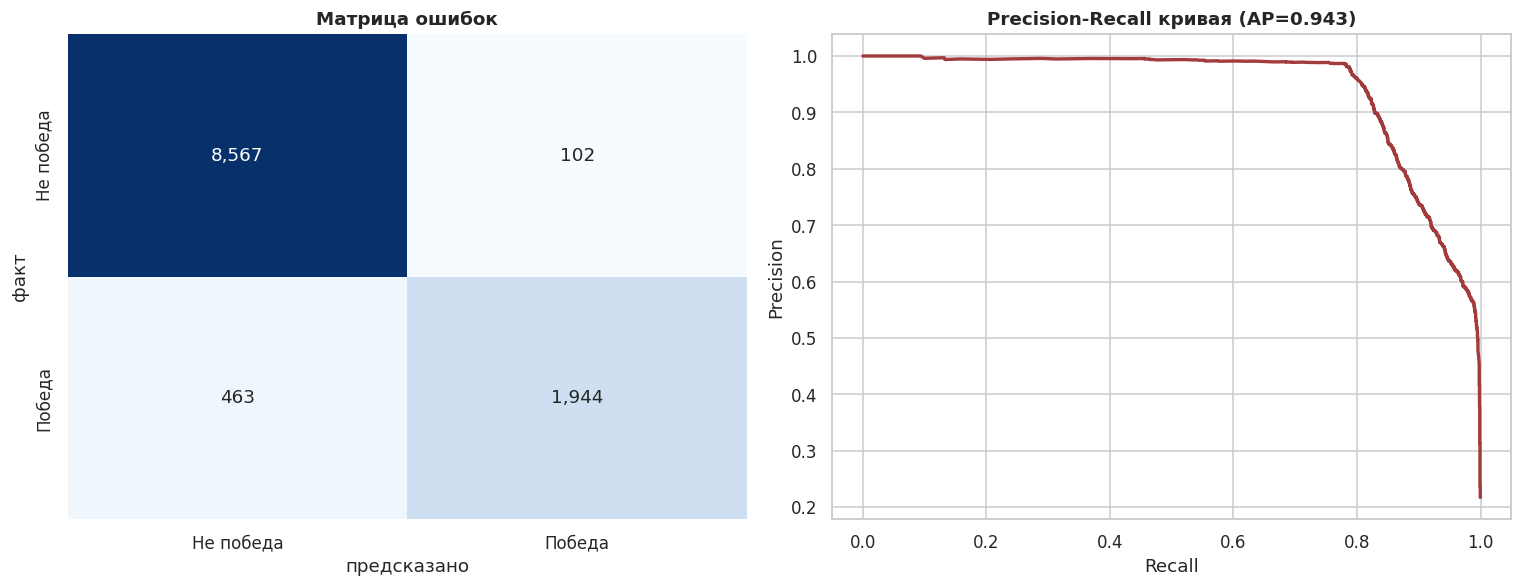

In [ ]:
threshold = 0.5
y_pred = (proba_tuned >= threshold).astype(int)

print("Отчёт классификации (порог = 0.5):")
print(classification_report(y_test, y_pred, target_names=["Не победа", "Победа"]))

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Матрица ошибок
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Не победа", "Победа"],
            yticklabels=["Не победа", "Победа"], ax=axes[0])
axes[0].set_title("Матрица ошибок", fontweight="bold")
axes[0].set_xlabel("предсказано")
axes[0].set_ylabel("факт")

# Precision-Recall кривая
prec, rec, _ = precision_recall_curve(y_test, proba_tuned)
axes[1].plot(rec, prec, color="#A23B3B", linewidth=2.2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall кривая (AP={average_precision_score(y_test, proba_tuned):.3f})",
                  fontweight="bold")

plt.tight_layout()
plt.savefig("неделя3_оценка_модели.png", dpi=130)
plt.show()

### 5.6 Важность признаков

Понимаем, **почему** модель принимает решения. Это критично: модель должна быть не только точной, но
и объяснимой. Смотрим, какие признаки вносят наибольший вклад в предсказание победы.


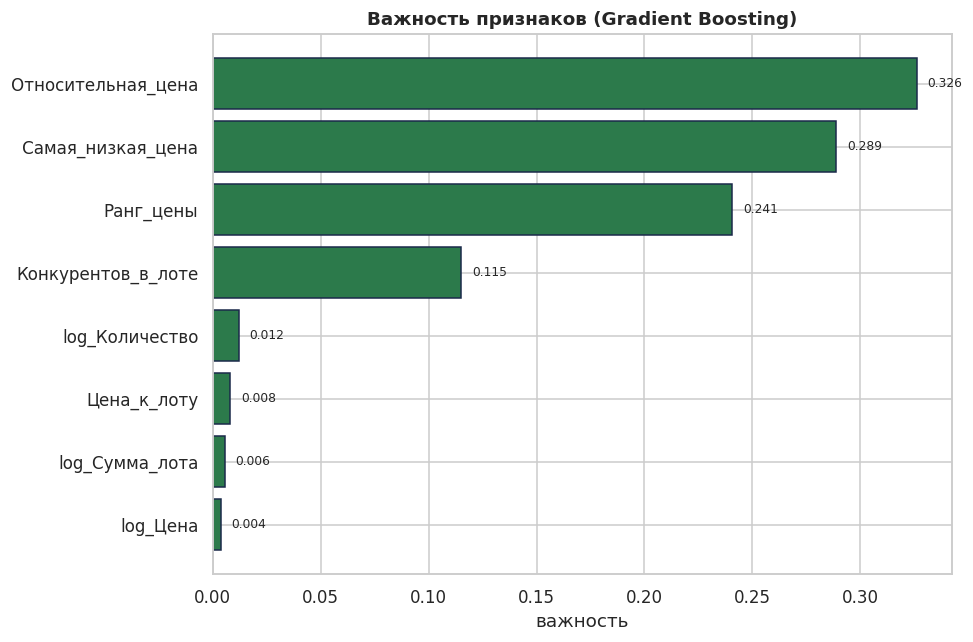

Признаки по важности (убывание):
Относительная_цена   0.326
Самая_низкая_цена    0.289
Ранг_цены            0.241
Конкурентов_в_лоте   0.115
log_Количество       0.012
Цена_к_лоту          0.008
log_Сумма_лота       0.006
log_Цена             0.004


In [ ]:
importances = pd.Series(best_model.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances.index, importances.values, color="#2C7A4B", edgecolor="#1B2A4A")
ax.set_title("Важность признаков (Gradient Boosting)", fontweight="bold")
ax.set_xlabel("важность")
for i, v in enumerate(importances.values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("неделя3_важность_признаков.png", dpi=130)
plt.show()

print("Признаки по важности (убывание):")
print(importances.sort_values(ascending=False).to_string())

## 6. Детектирование аномалий (Isolation Forest)

Дополнительный продвинутый анализ: ищем **аномальные заявки** - например, подозрительно низкие или
высокие цены относительно общей картины. Это применимо для выявления потенциальных аномалий в
закупках (демпинг, ошибки ввода, нетипичные лоты).

Используем **Isolation Forest** - алгоритм без учителя, изолирующий аномалии случайными разбиениями.


In [ ]:
anomaly_features = ["log_Цена", "log_Количество", "log_Сумма_лота", "Относительная_цена"]
X_anom = df[anomaly_features].replace([np.inf, -np.inf], np.nan).fillna(df[anomaly_features].median())

iso = IsolationForest(contamination=0.02, random_state=42, n_estimators=200)
df["Аномалия"] = (iso.fit_predict(X_anom) == -1).astype(int)

n_anom = df["Аномалия"].sum()
print(f"Обнаружено аномалий: {n_anom:,} ({n_anom/len(df)*100:.1f}% заявок)")
print()
print("Сравнение нормальных и аномальных заявок (медианы):")
comparison = df.groupby("Аномалия")[["Цена заявки", "Количество", "Сумма лота"]].median()
comparison.index = ["Нормальные", "Аномальные"]
print(comparison)

Обнаружено аномалий: 886 (2.0% заявок)

Сравнение нормальных и аномальных заявок (медианы):
            Цена заявки  Количество     Сумма лота
Нормальные    2,470.000      18.000    111,750.000
Аномальные    9,419.500      52.000 10,781,284.500


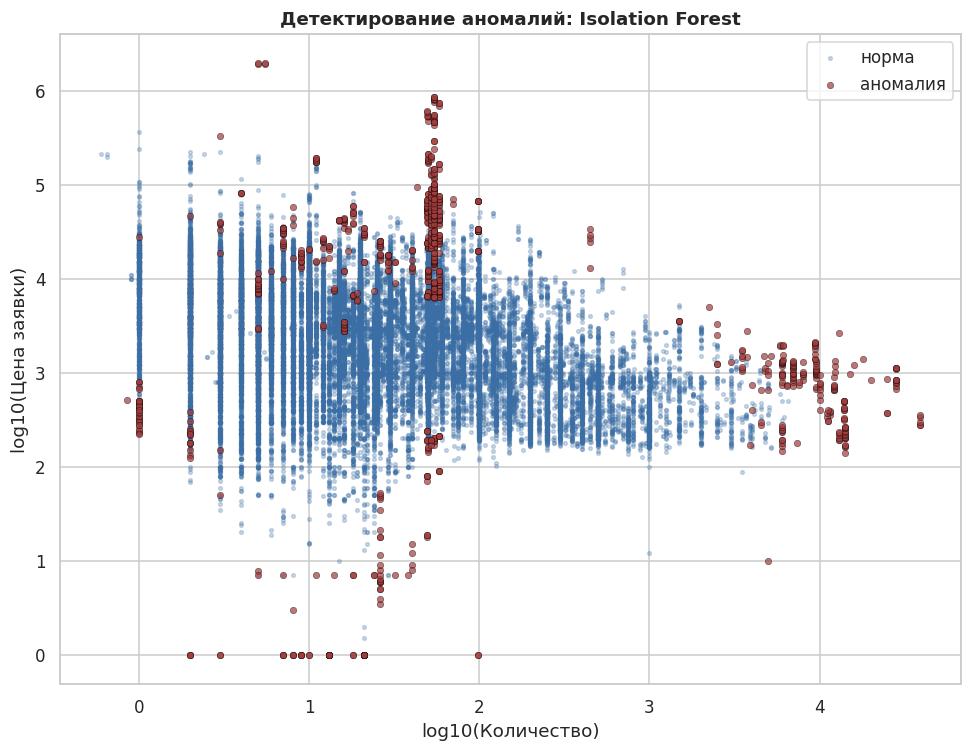

In [ ]:
# Визуализация аномалий: цена vs количество (лог-лог)
fig, ax = plt.subplots(figsize=(9, 7))

normal = df[df["Аномалия"] == 0]
anom = df[df["Аномалия"] == 1]

ax.scatter(normal["log_Количество"], normal["log_Цена"],
           s=6, alpha=0.25, color="#3A6EA5", label="норма")
ax.scatter(anom["log_Количество"], anom["log_Цена"],
           s=18, alpha=0.7, color="#A23B3B", label="аномалия", edgecolor="black", linewidth=0.3)

ax.set_xlabel("log10(Количество)")
ax.set_ylabel("log10(Цена заявки)")
ax.set_title("Детектирование аномалий: Isolation Forest", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("неделя3_аномалии.png", dpi=130)
plt.show()

## 7. Сводный дашборд

Собираем ключевые результаты недели в единую панель из нескольких графиков - компактное визуальное
резюме всего анализа.


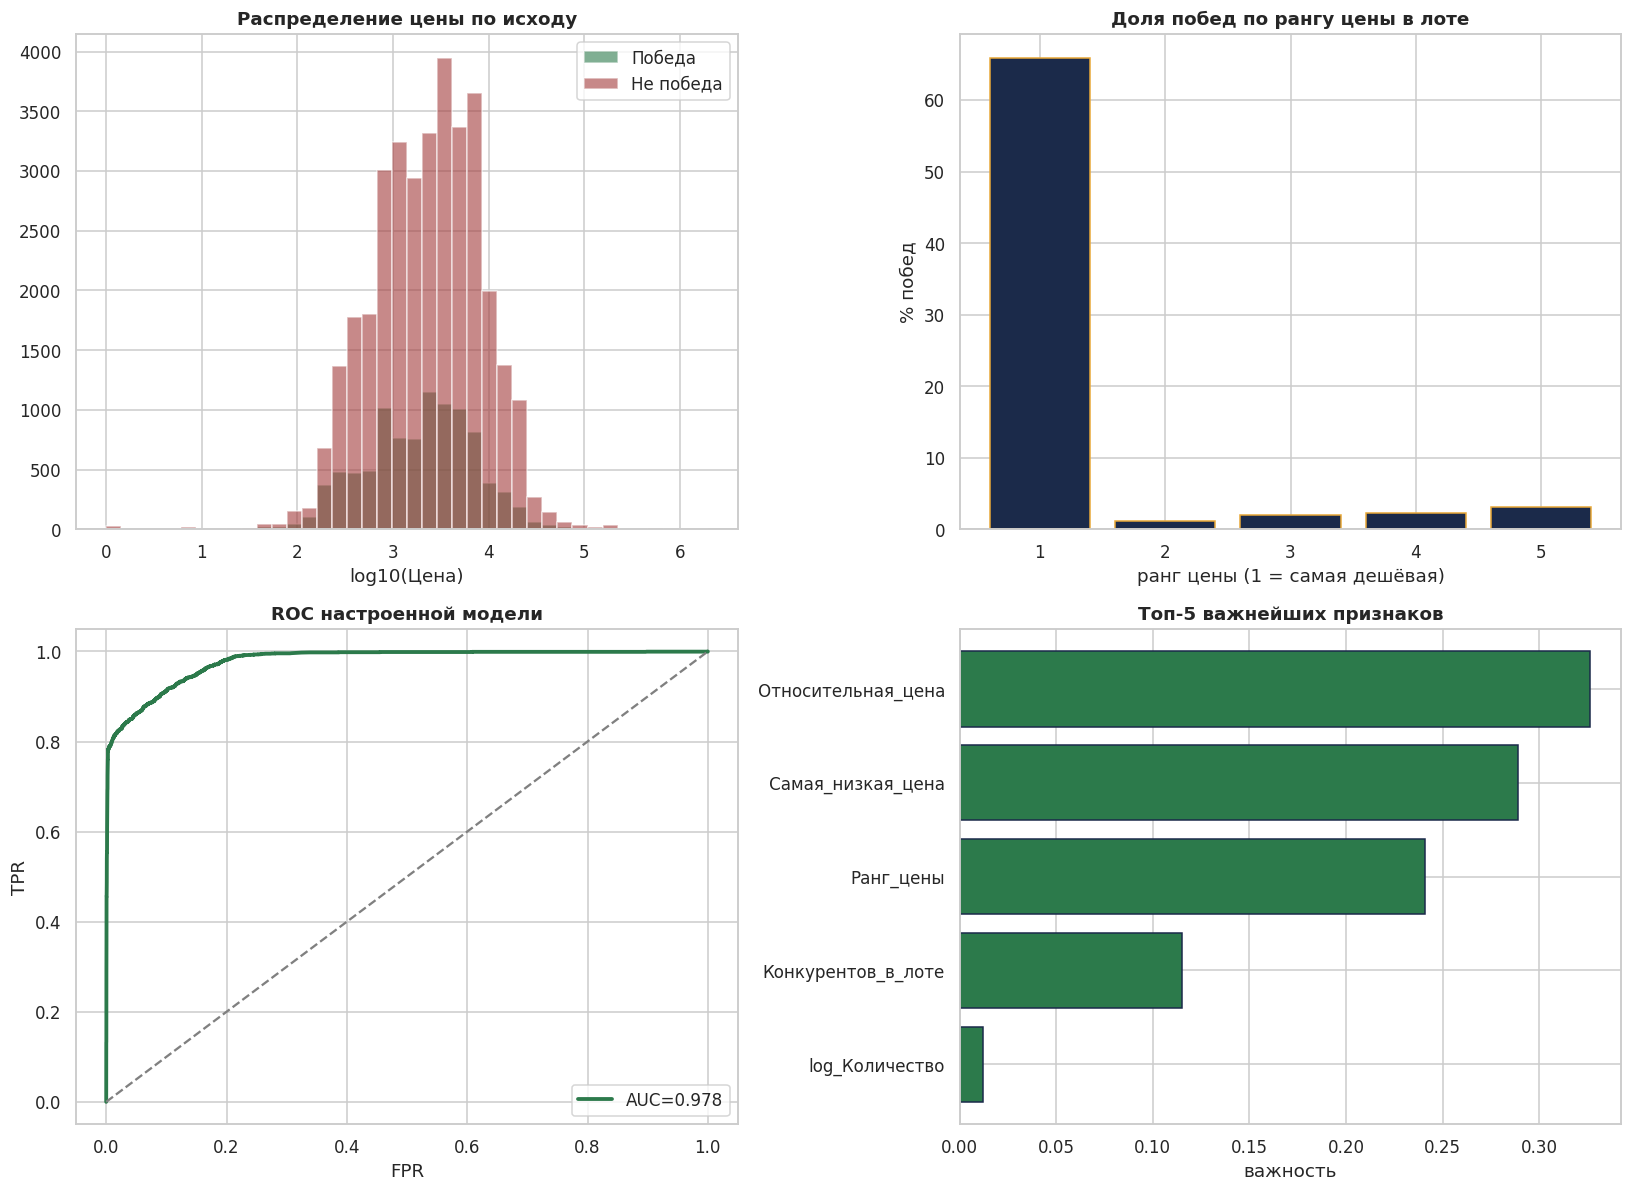

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# (1) Распределение цены по исходу
for label, color, name in [(1, "#2C7A4B", "Победа"), (0, "#A23B3B", "Не победа")]:
    sub = df[df["Победа"] == label]["log_Цена"]
    axes[0, 0].hist(sub, bins=40, alpha=0.6, color=color, label=name)
axes[0, 0].set_title("Распределение цены по исходу", fontweight="bold")
axes[0, 0].set_xlabel("log10(Цена)")
axes[0, 0].legend()

# (2) Win rate по рангу цены
rank_win = df[df["Ранг_цены"] <= 5].groupby("Ранг_цены")["Победа"].mean() * 100
axes[0, 1].bar(rank_win.index.astype(int), rank_win.values, color="#1B2A4A", edgecolor="#E8A838")
axes[0, 1].set_title("Доля побед по рангу цены в лоте", fontweight="bold")
axes[0, 1].set_xlabel("ранг цены (1 = самая дешёвая)")
axes[0, 1].set_ylabel("% побед")

# (3) ROC лучшей модели
fpr, tpr, _ = roc_curve(y_test, proba_tuned)
axes[1, 0].plot(fpr, tpr, color="#2C7A4B", linewidth=2.5, label=f"AUC={auc_tuned:.3f}")
axes[1, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[1, 0].set_title("ROC настроенной модели", fontweight="bold")
axes[1, 0].set_xlabel("FPR")
axes[1, 0].set_ylabel("TPR")
axes[1, 0].legend(loc="lower right")

# (4) Топ-5 признаков
top5 = importances.sort_values(ascending=False).head(5).sort_values()
axes[1, 1].barh(top5.index, top5.values, color="#2C7A4B", edgecolor="#1B2A4A")
axes[1, 1].set_title("Топ-5 важнейших признаков", fontweight="bold")
axes[1, 1].set_xlabel("важность")

plt.tight_layout()
plt.savefig("неделя3_дашборд.png", dpi=130)
plt.show()

## 8. Итоги Недели 3

**Что выполнено**

1. **EDA:** распределения (лог-шкала), корреляции Спирмена, анализ по заказчикам/категориям,
   помесячные временные тренды.
2. **Статистика:** тест Манна-Уитни (цена победителей значимо ниже, p ≈ 10⁻³³) и хи-квадрат
   (связь победы с конкуренцией).
3. **Инженерия признаков:** ранг цены в лоте, признак самой низкой цены, относительная цена,
   уровень конкуренции, лог-преобразования.
4. **Моделирование:** сравнение трёх моделей по ROC-AUC, ROC-кривые, подбор гиперпараметров через
   GridSearchCV, детальная оценка (матрица ошибок, precision/recall, PR-кривая), важность признаков.
5. **Аномалии:** Isolation Forest для поиска нетипичных заявок.
6. **Дашборд:** сводная панель ключевых результатов.

**Ключевые выводы**

- Главный фактор победы - **ранг цены внутри лота**: самая дешёвая заявка побеждает в ~66% случаев
  против ~5% у остальных.
- Цена победителей **статистически значимо** ниже (p ≈ 10⁻³³).
- Настроенная модель Gradient Boosting достигает высокого ROC-AUC, и её решения **объяснимы** через
  важность признаков.